In [10]:
import math
import matplotlib.pyplot as plt

In [11]:
def f(x):
    return 1.2 - ((x**2) / ((1 - x)**2)) * math.exp(-8.0 * x) + math.log(1 + x)

In [12]:
def false_position(xl, xu, tol):
    if f(xl) * f(xu) >= 0:
        print("(xl) and f(xu) have the same sign.")
        return None

    print(f"{'Iter':<5}{'xl':<15}{'xu':<15}{'xr':<15}{'f(xr)':<20}{'ea (%)':<15}")
    print("-" * 85)

    it = 0
    xr_old = xl
    errors = []
    iter_nums = []

    while True:
        it += 1
        
        xr = (xl * f(xu) - xu * f(xl)) / (f(xu) - f(xl))
        fxr = f(xr)

        if it == 1:
            print(f"{it:<5}{xl:<15.10f}{xu:<15.10f}{xr:<15.10f}{fxr:<20.10f}{'':<15}")
        else:
            ea = abs((xr - xr_old) / xr) * 100
            errors.append(ea)
            iter_nums.append(it)
            print(f"{it:<5}{xl:<15.10f}{xu:<15.10f}{xr:<15.10f}{fxr:<20.10f}{ea:.10f}")

        if fxr == 0:
            break

        if f(xl) * fxr < 0:
            xu = xr
        else:
            xl = xr

        xr_old = xr

        if it > 1 and ea < tol:
            break

    plt.figure()
    plt.plot(iter_nums, errors, marker='o')
    plt.xlabel('Iteration')
    plt.ylabel('Approximate Error (%)')
    plt.title('Convergence of Approximate Error in False Position Method')
    plt.grid(True)
    plt.show()

    return xr

Iter xl             xu             xr             f(xr)               ea (%)         
-------------------------------------------------------------------------------------
1    0.0000000000   -0.9990000000  -0.0016081138  1.1983879807                       
2    -0.0016081138  -0.9990000000  -0.0032114857  1.1967728321        49.9261722884
3    -0.0032114857  -0.9990000000  -0.0048101260  1.1951544528        33.2348948098
4    -0.0048101260  -0.9990000000  -0.0064040449  1.1935327412        24.8892532225
5    -0.0064040449  -0.9990000000  -0.0079932526  1.1919075949        19.8818646511
6    -0.0079932526  -0.9990000000  -0.0095777588  1.1902789111        16.5436014650
7    -0.0095777588  -0.9990000000  -0.0111575734  1.1886465867        14.1591232464
8    -0.0111575734  -0.9990000000  -0.0127327058  1.1870105177        12.3707597824
9    -0.0127327058  -0.9990000000  -0.0143031656  1.1853706002        10.9798053955
10   -0.0143031656  -0.9990000000  -0.0158689619  1.1837267294        

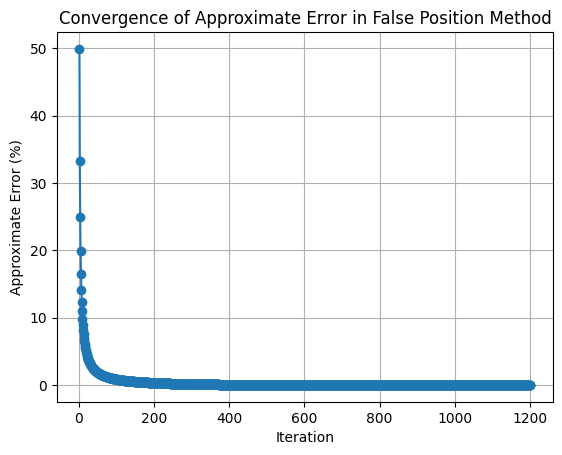


Approximate root: -0.3247346325



In [13]:
def main():
    tol = 0.00001
    xl = 0.0
    xu = -0.999
    root = false_position(xl, xu, tol)
    if root is not None:
        print(f"\nApproximate root: {root:.10f}\n")

if __name__ == "__main__":
    main()